In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C

Function 3: Drug Discovery Problem

In this example, you are doing drug discovery! You can select three compounds to create a drug, and receive a measurement of the people’s adverse reaction to the drug. You want to make this as close as possible to zero. (hint: one of the variables may not cause any effects on the person).

**Scenario**
- We simulate the process of designing a new drug by combining three different compounds.
- For each combination, we receive a measurement of the **adverse reaction** in people (i.e., how bad the side effects are).

**Goal**
- **Minimize the adverse reaction**: We want to find the combination of the three compounds that results in the smallest possible adverse reaction (ideally, as close to zero as possible).

**Key Details**
- **Three variables**: Each variable represents the amount or presence of a specific compound in the drug.
- **Adverse reaction measurement**: For each combination, you get a number (the output, `y`). The closer this number is to zero, the better (less harmful).
- **Hint**: One of the compounds may not actually affect the adverse reaction at all. This means the problem may have a "flat" direction—changing that compound doesn’t change the outcome.

**Real-World Analogy**
Imagine you are a pharmaceutical scientist:
- You can mix three ingredients in different proportions to make a pill.
- You test each pill on people and measure how bad the side effects are.
- Your job is to find the recipe that causes the least harm.

In [2]:
def queries_for_function(number):
    if number < 1 or number > 8:
        return []
        
    with open('../queries.txt', 'r') as file:  # Fixed the path separator for cross-platform compatibility
        file_content = file.read()
        
    all_queries = file_content.split('])]')
    
    formatted_queries = [query.replace('\n', '') + '])]' for query in all_queries if query]
    
    actual_queries = []
    for query in formatted_queries:
        formatted_query = query.replace('array(', '').replace(')', '').strip()
        
        try:
            query_formatted_as_list = eval(formatted_query)  # Ensure eval is safe or replace with a safer alternative
            query_as_2d_array = np.array(query_formatted_as_list, dtype=object)
            actual_queries.append(query_as_2d_array[number - 1])
        except (SyntaxError, IndexError, ValueError) as e:
            print(f"Warning: Skipping query due to error - {e}")
            continue

    return actual_queries


def observations_for_function(number):
    if number < 1 or number > 8:
        return []
    
    data = []
    
    with open('../observations.txt', 'r') as file:  # Fixed the path separator for cross-platform compatibility
        for line in file:
            try:
                # Extract the float values from the line
                values = [float(value.split('(')[1].split(')')[0]) for value in line.strip().split(', ')]
                data.append(values)
            except (IndexError, ValueError) as e:
                print(f"Warning: Skipping line due to error - {e}")
                continue
            
    # Convert the list of lists into a numpy array
    data_array = np.array(data)
    
    # Extract each column as a numpy array
    columns = [data_array[:, i] for i in range(data_array.shape[1])] if data_array.size > 0 else []
    
    return columns[number - 1] if number - 1 < len(columns) else []

In [3]:
X = np.load("initial_inputs.npy")
X, len(X)

(array([[0.17152521, 0.34391687, 0.2487372 ],
        [0.24211446, 0.64407427, 0.27243281],
        [0.53490572, 0.39850092, 0.17338873],
        [0.49258141, 0.61159319, 0.34017639],
        [0.13462167, 0.21991724, 0.45820622],
        [0.34552327, 0.94135983, 0.26936348],
        [0.15183663, 0.43999062, 0.99088187],
        [0.64550284, 0.39714294, 0.91977134],
        [0.74691195, 0.28419631, 0.22629985],
        [0.17047699, 0.6970324 , 0.14916943],
        [0.22054934, 0.29782524, 0.34355534],
        [0.66601366, 0.67198515, 0.2462953 ],
        [0.04680895, 0.23136024, 0.77061759],
        [0.60009728, 0.72513573, 0.06608864],
        [0.96599485, 0.86111969, 0.56682913]]),
 15)

In [4]:
#new_query_1 =  np.array([1.00000e-06, 9.99999e-01])
#new_query_2 =  np.array([0.999999, 0.999999])
#new_query_3 =  np.array([1.e-06, 1.e-06])
#new_query_4 =  np.array([9.99999e-01, 1.00000e-06])
#new_query_5 =  np.array([6.76767e-01, 1.00000e-06])
#X = np.vstack([X, new_query_1, new_query_2, new_query_3, new_query_4, new_query_5])
#X

queries = queries_for_function(3)
X = np.vstack([X, queries])
X, len(X)

(array([[1.71525207e-01, 3.43916870e-01, 2.48737201e-01],
        [2.42114461e-01, 6.44074270e-01, 2.72432809e-01],
        [5.34905720e-01, 3.98500915e-01, 1.73388729e-01],
        [4.92581415e-01, 6.11593188e-01, 3.40176386e-01],
        [1.34621666e-01, 2.19917240e-01, 4.58206220e-01],
        [3.45523271e-01, 9.41359831e-01, 2.69363479e-01],
        [1.51836632e-01, 4.39990619e-01, 9.90881867e-01],
        [6.45502835e-01, 3.97142940e-01, 9.19771338e-01],
        [7.46911945e-01, 2.84196309e-01, 2.26299855e-01],
        [1.70476994e-01, 6.97032401e-01, 1.49169434e-01],
        [2.20549337e-01, 2.97825244e-01, 3.43555344e-01],
        [6.66013659e-01, 6.71985151e-01, 2.46295297e-01],
        [4.68089497e-02, 2.31360241e-01, 7.70617592e-01],
        [6.00097282e-01, 7.25135725e-01, 6.60886415e-02],
        [9.65994849e-01, 8.61119690e-01, 5.66829131e-01],
        [9.99999000e-01, 1.00000000e-06, 6.66666000e-01],
        [1.00000000e-06, 9.52380000e-01, 7.14285000e-01],
        [9.999

In [5]:
y = np.load("initial_outputs.npy")
y, len(y)

(array([-0.1121222 , -0.08796286, -0.11141465, -0.03483531, -0.04800758,
        -0.11062091, -0.39892551, -0.11386851, -0.13146061, -0.09418956,
        -0.04694741, -0.10596504, -0.11804826, -0.03637783, -0.05675837]),
 15)

In [6]:
#y = np.append(y, [0.0, 1.517648729565899e-192, 2.31546114628124e-248, 0.0, 5.4713831123687026e-170], axis=0)
#y

observations = observations_for_function(3)
for observation in observations:
    y = np.append(y, [observation], axis=0)
y, len(y)

(array([-0.1121222 , -0.08796286, -0.11141465, -0.03483531, -0.04800758,
        -0.11062091, -0.39892551, -0.11386851, -0.13146061, -0.09418956,
        -0.04694741, -0.10596504, -0.11804826, -0.03637783, -0.05675837,
        -0.17890804, -0.13934594, -0.15108687, -0.47622425, -0.18298379,
        -0.10994809, -0.12012704, -0.09298749, -0.25947268, -0.05643452,
        -0.47721145, -0.4856915 , -0.17239566, -0.0172486 , -0.02230682,
        -0.03575413, -0.01168218]),
 32)

In [7]:
best_idx = np.argmax(y)
print("Best input so far:", X[best_idx])
print("Best output so far:", y[best_idx])

Best input so far: [0.478572 0.330953 0.473809]
Best output so far: -0.011682182780628726


In [8]:
def best_observation(y):
    best_idx = np.argmin(np.abs(y))  # Find the index where y is closest to zero
    best_observation_so_far = y[best_idx]
    best_query_so_far = X[best_idx]
    print("Best observation so far (closest to zero):", best_observation_so_far)
    print("Best query so far:", best_query_so_far)
    return best_observation_so_far, best_query_so_far

best_observation_so_far, best_query_so_far = best_observation(y)

Best observation so far (closest to zero): -0.011682182780628726
Best query so far: [0.478572 0.330953 0.473809]


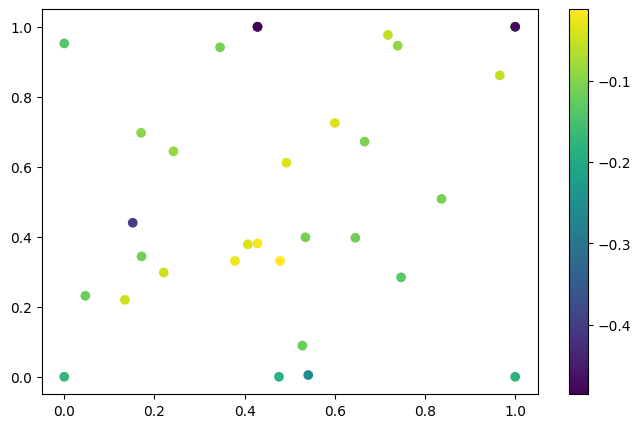

In [9]:
fig, ax = plt.subplots()
fig.set_figheight(5)
fig.set_figwidth(8)
plt.scatter(X[:, 0], X[:, 1], c = y)
plt.colorbar()

Text(0.5, 0.92, 'Scatter Plot of Contamination Sources Input Data Points with Output Variable y')

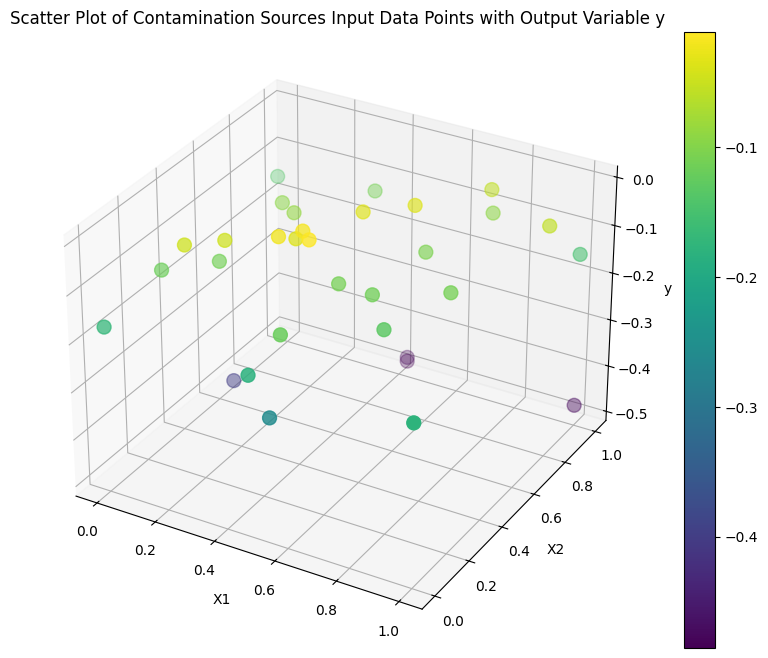

In [10]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
sc = ax.scatter(X[:,0], X[:,1], y, c=y, cmap='viridis', s=100)

plt.colorbar(sc)
ax.set_xlabel('X1')
ax.set_ylabel('X2')
ax.set_zlabel('y')

ax.set_title('Scatter Plot of Contamination Sources Input Data Points with Output Variable y')


**Acquisition Functions**

In [11]:
#UCB is useful when you want a balance between exploring new areas of the search space (high uncertainty) and exploiting known areas 
#with high mean values. The parameter β controls this balance. It's a good general-purpose acquisition function for many optimization problems.
def upper_confidence_bound(post_mean, post_std, beta):
    ucb = post_mean + beta * post_std # upper confidence bpon (ucb) = mu + kappa * sigma 
    print("\n\nUCB Shape: ", np.shape(ucb))
    return ucb


#PI is more focused on exploitation, as it prioritizes areas where the predicted mean is higher than the current best observed value (ymax)
#Use PI when you have a well-calibrated model and you want to focus on improving the best observed value.
def probability_of_improvement(post_mean, post_std, y_max):
    # Calculate the improvement
    improvement = post_mean - y_max
    
    # Calculate the Z value
    Z = improvement / post_std
    
    # Calculate the probability of improvement using the cumulative distribution function (CDF) of the normal distribution
    PI = norm.cdf(Z)
    print("\n\nPI Shape: ", np.shape(PI))
    return PI


def probability_of_improvement_with_exploration_term(post_mean, post_std, y_max, epsilon):
    # Calculate the improvement with exploration term
    improvement = post_mean - (y_max + epsilon)
    
    # Calculate the Z value
    Z = improvement / post_std
    
    # Calculate the probability of improvement using the cumulative distribution function (CDF) of the normal distribution
    PI = norm.cdf(Z)
    print("\n\nPI With Exploitation Term Shape: ", np.shape(PI))
    return PI


#EI provides a balance between exploration and exploitation, similar to UCB, but it also considers the magnitude of improvement.
#Use EI when you want to maximize the expected improvement over the current best observed value.
def expected_improvement(post_mean, post_std, y_max):
    # Calculate the improvement
    improvement = post_mean - y_max
    
    # Calculate the Z value
    Z = improvement / post_std
    
    # Calculate the expected improvement
    EI = improvement * norm.cdf(Z) + post_std * norm.pdf(Z)
    print("\n\nEI Shape: ", np.shape(EI))
    return EI

#Thompson Sampling is useful when you want to sample from the posterior distribution of the model, which inherently balances exploration and exploitation.
#Use Thompson Sampling when you want a stochastic approach to selecting the next point.
def thompson_sampling(post_mean, post_std):
    # Sample from the posterior distribution
    samples = np.random.normal(post_mean, post_std)
    print("\n\nThompson Samples Shape: ", np.shape(samples))
    return samples

**Input Sampling Methods**

In [12]:
def exploration_grid():
    x1_grid = np.linspace(0.000001, 0.999999, 22)
    x2_grid = np.linspace(0.000001, 0.999999, 22)
    x3_grid = np.linspace(0.000001, 0.999999, 22)

    x1_grid, x2_grid, x3_grid = np.meshgrid(x1_grid, x2_grid, x3_grid)    
    x_grid = np.vstack([x1_grid.ravel(), x2_grid.ravel(), x3_grid.ravel()]).T

    return x_grid

def exploitation_grid(center, delta=0.05):
    """
    Create a grid for exploitation around the given center point (array of 4 values).
    delta: half-width of the interval to explore around each coordinate.
    """
    x1, x2, x3 = center
    x1_grid = np.linspace(max(0.000001, x1 - delta), min(0.999999, x1 + delta), 22)
    x2_grid = np.linspace(max(0.000001, x2 - delta), min(0.999999, x2 + delta), 22)
    x3_grid = np.linspace(max(0.000001, x3 - delta), min(0.999999, x3 + delta), 22)

    x1_grid, x2_grid, x3_grid = np.meshgrid(x1_grid, x2_grid, x3_grid)    
    x_grid = np.vstack([x1_grid.ravel(), x2_grid.ravel(), x3_grid.ravel()]).T

    return x_grid

def exploration_latin_hypercube():
    """
    Create a Latin Hypercube sample for exploration.
    """
    from scipy.stats import qmc
    n_samples = 10000
    bounds = [
        (0.000001, 0.999999),  # x1
        (0.000001, 0.999999),  # x2
        (0.000001, 0.999999)   # x3
    ]
    sampler = qmc.LatinHypercube(d=3)
    lhs_sample = sampler.random(n=n_samples)
    l_bounds = np.array([b[0] for b in bounds])
    u_bounds = np.array([b[1] for b in bounds])
    lhs_samples = qmc.scale(lhs_sample, l_bounds, u_bounds)
    return lhs_samples

def exploitation_latin_hypercube(center, delta=0.05):
    """
    Create a Latin Hypercube sample for exploitation around the given center point (array of 4 values).
    delta: half-width of the interval to explore around each coordinate.
    """
    from scipy.stats import qmc
    n_samples = 10000
    bounds = [
        (max(0.000001, center[0] - delta), min(0.999999, center[0] + delta)),  # x1
        (max(0.000001, center[1] - delta), min(0.999999, center[1] + delta)),  # x2
        (max(0.000001, center[2] - delta), min(0.999999, center[2] + delta))   # x3
    ]
    sampler = qmc.LatinHypercube(d=3)
    lhs_sample = sampler.random(n=n_samples)
    l_bounds = np.array([b[0] for b in bounds])
    u_bounds = np.array([b[1] for b in bounds])
    lhs_samples = qmc.scale(lhs_sample, l_bounds, u_bounds)
    return lhs_samples

In [13]:
def query_black_box_function_with_default_kernel(X, y, x_grid, acquisition_func):
    
    beta = 1.96
    model = GaussianProcessRegressor()
    model.fit(X, y)

    
    #x1_grid, x2_grid, x3_grid = np.meshgrid(x1_grid, x2_grid, x3_grid)
    #x_grid = np.vstack([x1_grid.ravel(), x2_grid.ravel(), x3_grid.ravel()]).T
    
    post_mean, post_std = model.predict(x_grid, return_std=True) #post_mean is y_pred and post_std is sigma i.e. s
    #acquisition_function = post_mean + beta * post_std # upper confidence bound (ucb) = mu + kappa * sigma mu + kappa * sigma 
    if acquisition_func == upper_confidence_bound:
        acquisition_function = acquisition_func(post_mean, post_std, beta)
        
    elif acquisition_func == probability_of_improvement:
        y_max = np.max(y)  # Define y_max as the maximum observed value
        acquisition_function = acquisition_func(post_mean, post_std, y_max)
        
    elif acquisition_func == probability_of_improvement_with_exploration_term:
        y_max = np.max(y)
        acquisition_function = acquisition_func(post_mean, post_std, y_max, 0.8)

    elif acquisition_func == expected_improvement:
        y_max = np.max(y)
        acquisition_function = acquisition_func(post_mean, post_std, y_max)

    else: #thompson_sampling
         acquisition_function = acquisition_func(post_mean, post_std)
    
    x = x_grid[np.argmax(acquisition_function)]
    y_pred = post_mean[np.argmax(acquisition_function)]
    
    x = x.reshape(1,3)
    y_pred = np.array([y_pred])
    
    print(f"Query to Black Box Function Maximizes at Input: ({x[0][0]:.6f}-{x[0][1]:.6f}-{x[0][2]:.6f})")
    print(f"Predicted Value at ({x[0][0]:.6f}-{x[0][1]:.6f}-{x[0][2]:.6f}) is {y_pred[0]}") 
    print("Index of maximum acquisition function value: ", np.argmax(acquisition_function))
    print("Kernel used: ", model.kernel_, "Score: ", model.score(X, y))
   
    return x, y_pred

In [14]:
def next_query_with_default_kernel(X, y, x_grid):
    x_random = np.random.uniform(size = 2)
    print(f"Random Query: {x_random[0]:.6f}-{x_random[1]:.6f}")

    x_ucb, y_pred_ucb = query_black_box_function_with_default_kernel(X, y, x_grid, upper_confidence_bound)
    
    x_pi, y_pred_pi = query_black_box_function_with_default_kernel(X, y, x_grid, probability_of_improvement)
    
    x_piet, y_pred_piet = query_black_box_function_with_default_kernel(X, y, x_grid, probability_of_improvement_with_exploration_term)
    
    x_ei, y_pred_ei = query_black_box_function_with_default_kernel(X, y, x_grid, expected_improvement)
    
    x_ts, y_pred_ts = query_black_box_function_with_default_kernel(X, y, x_grid, thompson_sampling)

    return x_ucb, y_pred_ucb, x_pi, y_pred_pi, x_piet, y_pred_piet, x_ei, y_pred_ei, x_ts, y_pred_ts

Exploration: Explore the whole space with defalut RBF Kernel

In [15]:
x_ucb, y_pred_ucb, x_pi, y_pred_pi, x_piet, y_pred_piet, x_ei, y_pred_ei, x_ts, y_pred_ts = next_query_with_default_kernel(X, y, exploration_grid())

Random Query: 0.317752-0.880078


UCB Shape:  (10648,)
Query to Black Box Function Maximizes at Input: (0.999999-0.000001-0.000001)
Predicted Value at (0.999999-0.000001-0.000001) is 6.600112555548549
Index of maximum acquisition function value:  462
Kernel used:  1**2 * RBF(length_scale=1) Score:  0.9999349347227734


PI Shape:  (10648,)
Query to Black Box Function Maximizes at Input: (0.000001-0.000001-0.095239)
Predicted Value at (0.000001-0.000001-0.095239) is 0.1363464817404747
Index of maximum acquisition function value:  2
Kernel used:  1**2 * RBF(length_scale=1) Score:  0.9999349347227734


PI With Exploitation Term Shape:  (10648,)
Query to Black Box Function Maximizes at Input: (0.000001-0.000001-0.571428)
Predicted Value at (0.000001-0.000001-0.571428) is 0.9374725595116615
Index of maximum acquisition function value:  12
Kernel used:  1**2 * RBF(length_scale=1) Score:  0.9999349347227734


EI Shape:  (10648,)
Query to Black Box Function Maximizes at Input: (0.999999-0.00000

Exploitation: Exploit around the ponts below

In [16]:
best_observation_so_far, best_query_so_far = best_observation(y)

Best observation so far (closest to zero): -0.011682182780628726
Best query so far: [0.478572 0.330953 0.473809]


In [17]:
x_ucb, y_pred_ucb, x_pi, y_pred_pi, x_piet, y_pred_piet, x_ei, y_pred_ei, x_ts, y_pred_ts = next_query_with_default_kernel(X, y,exploitation_grid(best_query_so_far))

Random Query: 0.352720-0.423855


UCB Shape:  (10648,)
Query to Black Box Function Maximizes at Input: (0.428572-0.280953-0.523809)
Predicted Value at (0.428572-0.280953-0.523809) is 0.027736831456422806
Index of maximum acquisition function value:  21
Kernel used:  1**2 * RBF(length_scale=1) Score:  0.9999349347227734


PI Shape:  (10648,)
Query to Black Box Function Maximizes at Input: (0.428572-0.280953-0.452380)
Predicted Value at (0.428572-0.280953-0.452380) is -0.00803346186876297
Index of maximum acquisition function value:  6
Kernel used:  1**2 * RBF(length_scale=1) Score:  0.9999349347227734


PI With Exploitation Term Shape:  (10648,)
Query to Black Box Function Maximizes at Input: (0.428572-0.280953-0.423809)
Predicted Value at (0.428572-0.280953-0.423809) is -0.02044570818543434
Index of maximum acquisition function value:  0
Kernel used:  1**2 * RBF(length_scale=1) Score:  0.9999349347227734


EI Shape:  (10648,)
Query to Black Box Function Maximizes at Input: (0.428572-0.

Hyperparameter Tuning: Find best hyperparameters Best Kernel and Hyperparameters with gp_minimize

In [18]:
from sklearn.gaussian_process.kernels import Matern, RationalQuadratic, DotProduct

def query_black_box_function_with_kernel_choice(X, y, x_grid, acquisition_func, kernel_type, rbf_lengthscale, noise_assumption, restarts, beta):
    # Define the kernel based on the kernel_type parameter
    if kernel_type == 'RBF':
        kernel = RBF(length_scale=rbf_lengthscale, length_scale_bounds=(1e-2, 1e2)) * C(1.0, (1e-3, 1e3))

    elif kernel_type == 'Matern':
        kernel = Matern(length_scale=rbf_lengthscale, length_scale_bounds=(1e-2, 1e2), nu=1.5)

    elif kernel_type == 'RationalQuadratic':
        kernel = RationalQuadratic(length_scale=rbf_lengthscale, alpha=1.0) * C(1.0, (1e-3, 1e3))
      
    elif kernel_type == 'DotProduct':
        kernel = DotProduct(sigma_0=1.0, sigma_0_bounds=(1e-3, 1e3)) + C(1.0, (1e-3, 1e3))
    else:
        kernel = None

    # Create and fit the Gaussian Process model
    if kernel is None:
        model = GaussianProcessRegressor()
    else:   
        model = GaussianProcessRegressor(kernel=kernel, alpha=noise_assumption, n_restarts_optimizer=restarts)

    model.fit(X, y)

    # Create the grid for predictions
    #x1_grid, x2_grid, x3_grid = np.meshgrid(x1_grid, x2_grid, x3_grid)
    #x_grid = np.vstack([x1_grid.ravel(), x2_grid.ravel(), x3_grid.ravel()]).T

    # Predict the mean and standard deviation
    post_mean, post_std = model.predict(x_grid, return_std=True)

    # Compute the acquisition function
    if acquisition_func == upper_confidence_bound:
        acquisition_function = acquisition_func(post_mean, post_std, beta)
    elif acquisition_func == probability_of_improvement:
        y_max = np.max(y)
        acquisition_function = acquisition_func(post_mean, post_std, y_max)
    elif acquisition_func == probability_of_improvement_with_exploration_term:
        y_max = np.max(y)
        acquisition_function = acquisition_func(post_mean, post_std, y_max, 0.8)
    elif acquisition_func == expected_improvement:
        y_max = np.max(y)
        acquisition_function = acquisition_func(post_mean, post_std, y_max)
    else:  # thompson_sampling
        acquisition_function = acquisition_func(post_mean, post_std)

    # Find the point that maximizes the acquisition function
    x = x_grid[np.argmax(acquisition_function)]
    y_pred = post_mean[np.argmax(acquisition_function)]

    x = x.reshape(1, 3)
    y_pred = np.array([y_pred])

    print(f"Query to Black Box Function Maximizes at Input: ({x[0][0]:.6f}-{x[0][1]:.6f}-{x[0][2]:.6f})")
    print(f"Predicted Value at ({x[0][0]:.6f}-{x[0][1]:.6f}-{x[0][2]:.6f}) is {y_pred[0]}") 
    print("Index of maximum acquisition function value: ", np.argmax(acquisition_function))
    print("Kernel used: ", kernel_type, "Score: ", model.score(X, y))
  
    return x, y_pred

In [19]:
# Install scikit-optimize if not already installed
%pip install scikit-optimize

from skopt import gp_minimize
from skopt.space import Real, Integer, Categorical
from skopt.utils import use_named_args

# Define the search space
search_space = [
    Real(0.01, 1.0, name='lengthscale'),
    Real(1e-10, 1e-1, name='noise_assumption'),
    Integer(0, 15, name='restarts'),
    Real(1.0, 3.0, name='beta'),
    Categorical([upper_confidence_bound, probability_of_improvement, 
                 probability_of_improvement_with_exploration_term, 
                 expected_improvement, thompson_sampling], name='acquisition_func'),
    Categorical(['RBF', 'Matern', 'RationalQuadratic', 'DotProduct'], name='kernel_type')
]

# Define the objective function
@use_named_args(search_space)
def objective_function_gp(lengthscale, noise_assumption, restarts, beta, acquisition_func, kernel_type):
    global best_x_ucb, best_y_pred_ucb, best_params

    next_query, y_pred = query_black_box_function_with_kernel_choice(
        X, y, exploration_grid(),
        acquisition_func=acquisition_func,
        kernel_type=kernel_type,
        rbf_lengthscale=lengthscale,
        noise_assumption=noise_assumption,
        restarts=restarts,
        beta=beta
    )
    
    # Return the negative of the prediction as we want to maximize y_pred_ucb
    return -y_pred[0]

# Perform Bayesian optimization
result = gp_minimize(
    func=objective_function_gp,
    dimensions=search_space,
    n_calls=50,  # Number of evaluations
    random_state=42
)

# Extract the best parameters
(best_rbf_lengthscale, best_noise_assumption, best_restarts, 
 best_beta, best_acquisition_func, best_kernel_type) = result.x
print(f"Best Parameters: rbf_lengthscale={best_rbf_lengthscale}, noise_assumption={best_noise_assumption}, "
      f"restarts={best_restarts}, beta={best_beta}, acquisition_func={best_acquisition_func.__name__}, "
      f"kernel_type={best_kernel_type}")

# Use the best parameters to query the black-box function
next_query, y_pred = query_black_box_function_with_kernel_choice(
    X, y, exploration_grid(),
    acquisition_func=best_acquisition_func,
    kernel_type=best_kernel_type,
    rbf_lengthscale=best_rbf_lengthscale, 
    noise_assumption=best_noise_assumption,
    restarts=best_restarts,
    beta=best_beta
)

next_query, y_pred

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: C:\Users\harji\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip




PI With Exploitation Term Shape:  (10648,)
Query to Black Box Function Maximizes at Input: (0.999999-0.000001-0.000001)
Predicted Value at (0.999999-0.000001-0.000001) is -0.026633687400052675
Index of maximum acquisition function value:  462
Kernel used:  RBF Score:  0.5093652576858524


UCB Shape:  (10648,)
Query to Black Box Function Maximizes at Input: (0.999999-0.000001-0.000001)
Predicted Value at (0.999999-0.000001-0.000001) is -0.09848037902619268
Index of maximum acquisition function value:  462
Kernel used:  RationalQuadratic Score:  0.4585535534696873


EI Shape:  (10648,)
Query to Black Box Function Maximizes at Input: (0.428572-0.857142-0.000001)
Predicted Value at (0.428572-0.857142-0.000001) is 0.040851529938694564
Index of maximum acquisition function value:  8910
Kernel used:  RBF Score:  0.999385949342184


Thompson Samples Shape:  (10648,)
Query to Black Box Function Maximizes at Input: (0.904761-0.000001-0.428572)
Predicted Value at (0.904761-0.000001-0.428572) is

C:\Users\harji\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\gaussian_process\kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__sigma_0 is close to the specified lower bound 0.001. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\harji\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\gaussian_process\kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__constant_value is close to the specified lower bound 0.001. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\harji\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\gaussian_process\kernels.py:442: ConvergenceWarning: The



PI With Exploitation Term Shape:  (10648,)
Query to Black Box Function Maximizes at Input: (0.999999-0.000001-0.000001)
Predicted Value at (0.999999-0.000001-0.000001) is 0.026184728650443745
Index of maximum acquisition function value:  462
Kernel used:  DotProduct Score:  0.45526871351579346


PI With Exploitation Term Shape:  (10648,)
Query to Black Box Function Maximizes at Input: (0.999999-0.000001-0.000001)
Predicted Value at (0.999999-0.000001-0.000001) is -0.06440114478643699
Index of maximum acquisition function value:  462
Kernel used:  Matern Score:  0.3547457093828328


EI Shape:  (10648,)
Query to Black Box Function Maximizes at Input: (0.999999-0.000001-0.000001)
Predicted Value at (0.999999-0.000001-0.000001) is 0.0292690651214067
Index of maximum acquisition function value:  462
Kernel used:  DotProduct Score:  0.45701372958198083


PI With Exploitation Term Shape:  (10648,)
Query to Black Box Function Maximizes at Input: (0.999999-0.000001-0.000001)
Predicted Value a

...

C:\Users\harji\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\gaussian_process\kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__sigma_0 is close to the specified lower bound 0.001. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\harji\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\gaussian_process\kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__constant_value is close to the specified lower bound 0.001. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(




UCB Shape:  (10648,)
Query to Black Box Function Maximizes at Input: (0.999999-0.000001-0.000001)
Predicted Value at (0.999999-0.000001-0.000001) is 0.035837476351758824
Index of maximum acquisition function value:  462
Kernel used:  DotProduct Score:  0.46223473830292594


UCB Shape:  (10648,)
Query to Black Box Function Maximizes at Input: (0.999999-0.000001-0.000001)
Predicted Value at (0.999999-0.000001-0.000001) is 0.042372703552246094
Index of maximum acquisition function value:  462
Kernel used:  DotProduct Score:  0.4642704759303079


UCB Shape:  (10648,)
Query to Black Box Function Maximizes at Input: (0.999999-0.000001-0.000001)
Predicted Value at (0.999999-0.000001-0.000001) is 0.042372703552246094
Index of maximum acquisition function value:  462
Kernel used:  DotProduct Score:  0.4642704759303079


C:\Users\harji\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\gaussian_process\kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__sigma_0 is close to the specified lower bound 0.001. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\harji\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\gaussian_process\kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__constant_value is close to the specified lower bound 0.001. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(




EI Shape:  (10648,)
Query to Black Box Function Maximizes at Input: (0.999999-0.000001-0.000001)
Predicted Value at (0.999999-0.000001-0.000001) is 0.024154814968277094
Index of maximum acquisition function value:  462
Kernel used:  DotProduct Score:  0.45466060546487364


UCB Shape:  (10648,)
Query to Black Box Function Maximizes at Input: (0.999999-0.000001-0.000001)
Predicted Value at (0.999999-0.000001-0.000001) is 0.042372703552246094
Index of maximum acquisition function value:  462
Kernel used:  DotProduct Score:  0.4642704759303079


UCB Shape:  (10648,)
Query to Black Box Function Maximizes at Input: (0.999999-0.000001-0.000001)
Predicted Value at (0.999999-0.000001-0.000001) is 0.042372703552246094
Index of maximum acquisition function value:  462
Kernel used:  DotProduct Score:  0.4642704759303079


UCB Shape:  (10648,)
Query to Black Box Function Maximizes at Input: (0.999999-0.000001-0.000001)
Predicted Value at (0.999999-0.000001-0.000001) is 0.042372703552246094
Index 

(array([[9.99999e-01, 1.00000e-06, 1.00000e-06]]), array([0.0423727]))

Exploration: Explore the whole space with Kernel of Choice and Best Hyperparameters with gp_minimize

In [20]:
next_query, y_pred = query_black_box_function_with_kernel_choice(X, y, exploration_grid(), 
                                                                acquisition_func=best_acquisition_func, 
                                                                kernel_type=best_kernel_type, rbf_lengthscale=best_rbf_lengthscale, 
                                                                noise_assumption=best_noise_assumption, restarts=best_restarts, beta=best_beta)

next_query, y_pred



UCB Shape:  (10648,)
Query to Black Box Function Maximizes at Input: (0.999999-0.000001-0.000001)
Predicted Value at (0.999999-0.000001-0.000001) is 0.042372703552246094
Index of maximum acquisition function value:  462
Kernel used:  DotProduct Score:  0.4642704759303079


(array([[9.99999e-01, 1.00000e-06, 1.00000e-06]]), array([0.0423727]))

Exploitation: Exploit around the ponts below

In [21]:
best_observation_so_far, best_query_so_far = best_observation(y)

Best observation so far (closest to zero): -0.011682182780628726
Best query so far: [0.478572 0.330953 0.473809]


In [22]:
next_query, y_pred = query_black_box_function_with_kernel_choice(X, y, exploitation_grid(best_query_so_far), 
                                                                acquisition_func=best_acquisition_func, 
                                                                kernel_type=best_kernel_type, rbf_lengthscale=best_rbf_lengthscale, 
                                                                noise_assumption=best_noise_assumption, restarts=best_restarts, beta=best_beta)
next_query, y_pred



UCB Shape:  (10648,)
Query to Black Box Function Maximizes at Input: (0.528572-0.280953-0.423809)
Predicted Value at (0.528572-0.280953-0.423809) is -0.10245037078857422
Index of maximum acquisition function value:  462
Kernel used:  DotProduct Score:  0.4642704759303079


(array([[0.528572, 0.280953, 0.423809]]), array([-0.10245037]))

Hyperparameter Tuning: Find best hyperparameters Best Kernel and Hyperparameters using from bayes_opt import BayesianOptimization

In [23]:
%pip install bayesian-optimization
from bayes_opt import BayesianOptimization


# Define the function to optimize
def objective_function_bo(lengthscale, noise_assumption, restarts, beta, kernel_type, acquisition_func):
    # Map integer values to kernel types and acquisition functions
    kernel_types = ['RBF', 'Matern', 'RationalQuadratic', 'DotProduct']
    acquisition_funcs = [
        upper_confidence_bound,
        probability_of_improvement,
        probability_of_improvement_with_exploration_term,
        expected_improvement,
        thompson_sampling
    ]
    kernel_type_str = kernel_types[int(round(kernel_type))]
    acquisition_func_obj = acquisition_funcs[int(round(acquisition_func))]

    next_query, y_pred = query_black_box_function_with_kernel_choice(
        X, y, exploration_grid(),
        acquisition_func=acquisition_func_obj,
        kernel_type=kernel_type_str,
        rbf_lengthscale=lengthscale,
        noise_assumption=noise_assumption,
        restarts=int(round(restarts)),
        beta=beta
    )
    # Return the negative of the prediction as we want to maximize y_pred_ucb
    return -y_pred[0]

# Define the bounds for each parameter
pbounds = {
    'lengthscale': (0.01, 1.0),
    'noise_assumption': (1e-10, 1e-1),
    'restarts': (0, 15),
    'beta': (1.0, 3.0),
    'kernel_type': (0, 3),  # 0: RBF, 1: Matern, 2: RationalQuadratic, 3: DotProduct
    'acquisition_func': (0, 4)  # 0: UCB, 1: PI, 2: PI+explore, 3: EI, 4: Thompson
}

optimizer = BayesianOptimization(
    f=objective_function_bo,
    pbounds=pbounds,
    random_state=42,
    verbose=2
)

optimizer.maximize(
    init_points=5,
    n_iter=50
)

# Extract the best parameters
best_params = optimizer.max['params']
best_rbf_lengthscale = best_params['lengthscale']
best_noise_assumption = best_params['noise_assumption']
best_restarts = int(round(best_params['restarts']))
best_beta = best_params['beta']
best_kernel_type = ['RBF', 'Matern', 'RationalQuadratic', 'DotProduct'][int(round(best_params['kernel_type']))]
best_acquisition_func = [
    upper_confidence_bound,
    probability_of_improvement,
    probability_of_improvement_with_exploration_term,
    expected_improvement,
    thompson_sampling
][int(round(best_params['acquisition_func']))]

print(f"Best Parameters: rbf_lengthscale={best_rbf_lengthscale}, noise_assumption={best_noise_assumption}, "
      f"restarts={best_restarts}, beta={best_beta}, kernel_type={best_kernel_type}, "
      f"acquisition_func={best_acquisition_func.__name__}")

# Use the best parameters to query the black-box function
next_query, y_pred = query_black_box_function_with_kernel_choice(
    X, y, exploration_grid(),
    acquisition_func=best_acquisition_func,
    kernel_type=best_kernel_type,
    rbf_lengthscale=best_rbf_lengthscale,
    noise_assumption=best_noise_assumption,
    restarts=best_restarts,
    beta=best_beta
)

next_query, y_pred



[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: C:\Users\harji\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
|   iter    |  target   | acquis... |   beta    | kernel... | length... | noise_... | restarts  |
-------------------------------------------------------------------------------------------------


PI Shape:  (10648,)
Query to Black Box Function Maximizes at Input: (0.476191-0.523809-0.000001)
Predicted Value at (0.476191-0.523809-0.000001) is -0.07237881663554835
Index of maximum acquisition function value:  5544
Kernel used:  RationalQuadratic Score:  0.7263782436930296
| 1         | 0.07238   | 1.498     | 2.901     | 2.196     | 0.6027    | 0.0156    | 2.34      |


UCB Shape:  (10648,)
Query to Black Box Function Maximizes at Input: (0.000001-0.999999-0.000001)
Predicted Value at (0.000001-0.999999-0.000001) is -0.11848924430096952
Index of maximum acquisition function value:  10164
Kernel used:  RationalQuadratic Score:  0.967803991665203

C:\Users\harji\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\gaussian_process\kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__sigma_0 is close to the specified lower bound 0.001. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\harji\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\gaussian_process\kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__constant_value is close to the specified lower bound 0.001. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\harji\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\gaussian_process\kernels.py:442: ConvergenceWarning: The



PI With Exploitation Term Shape:  (10648,)
Query to Black Box Function Maximizes at Input: (0.999999-0.000001-0.000001)
Predicted Value at (0.999999-0.000001-0.000001) is -0.12191420982304864
Index of maximum acquisition function value:  462
Kernel used:  RationalQuadratic Score:  -0.02733286615697561
| 10        | 0.1219    | 1.516     | 1.608     | 2.227     | 0.03215   | 0.1       | 6.398     |


PI With Exploitation Term Shape:  (10648,)
Query to Black Box Function Maximizes at Input: (0.999999-0.000001-0.000001)
Predicted Value at (0.999999-0.000001-0.000001) is -0.12191421984752342
Index of maximum acquisition function value:  462
Kernel used:  RationalQuadratic Score:  -0.027332840365996924
| 11        | 0.1219    | 2.0       | 2.426     | 2.377     | 0.01      | 0.1       | 6.021     |


C:\Users\harji\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\gaussian_process\kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__sigma_0 is close to the specified lower bound 0.001. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\harji\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\gaussian_process\kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__constant_value is close to the specified lower bound 0.001. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


...



EI Shape:  (10648,)
Query to Black Box Function Maximizes at Input: (0.428572-0.380953-0.476191)
Predicted Value at (0.428572-0.380953-0.476191) is -0.08843994140625
Index of maximum acquisition function value:  4080
Kernel used:  RationalQuadratic Score:  0.9999350883059474
| 50        | 0.08844   | 3.278     | 1.0       | 2.288     | 0.01      | 1e-10     | 3.476     |


UCB Shape:  (10648,)
Query to Black Box Function Maximizes at Input: (0.000001-0.999999-0.000001)
Predicted Value at (0.000001-0.999999-0.000001) is -0.05632189930700049
Index of maximum acquisition function value:  10164
Kernel used:  RBF Score:  0.6720920500645098
| 51        | 0.05632   | 0.1026    | 1.188     | 0.2347    | 0.1076    | 0.01421   | 4.833     |


PI Shape:  (10648,)
Query to Black Box Function Maximizes at Input: (0.000001-0.999999-0.000001)
Predicted Value at (0.000001-0.999999-0.000001) is -0.09978568934515764
Index of maximum acquisition function value:  10164
Kernel used:  Matern Score:  0.923

C:\Users\harji\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\gaussian_process\kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__sigma_0 is close to the specified lower bound 0.001. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\harji\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\gaussian_process\kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__constant_value is close to the specified lower bound 0.001. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(




PI Shape:  (10648,)
Query to Black Box Function Maximizes at Input: (0.095239-0.000001-0.000001)
Predicted Value at (0.095239-0.000001-0.000001) is 0.003483887982385636
Index of maximum acquisition function value:  44
Kernel used:  DotProduct Score:  0.45466060546487364
| 53        | -0.003484 | 1.214     | 1.0       | 2.826     | 0.01      | 0.1       | 1.943     |


Thompson Samples Shape:  (10648,)
Query to Black Box Function Maximizes at Input: (0.999999-0.095239-0.190477)
Predicted Value at (0.999999-0.095239-0.190477) is -0.06867140927672644
Index of maximum acquisition function value:  1434
Kernel used:  Matern Score:  0.633242272741416
| 54        | 0.06867   | 3.831     | 2.064     | 0.9503    | 0.9526    | 0.01659   | 5.942     |


EI Shape:  (10648,)
Query to Black Box Function Maximizes at Input: (0.000001-0.000001-0.000001)
Predicted Value at (0.000001-0.000001-0.000001) is -0.12191371975665731
Index of maximum acquisition function value:  0
Kernel used:  RationalQuadrat

C:\Users\harji\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\gaussian_process\kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


(array([[9.99999e-01, 1.00000e-06, 1.00000e-06]]), array([-0.14163]))

Exploration: Explore the whole space with Kernel of Choice and Best Hyperparameters with BaysianOptimization

In [24]:
next_query, y_pred = query_black_box_function_with_kernel_choice(X, y, exploration_latin_hypercube(), 
                                                                acquisition_func=best_acquisition_func, 
                                                                kernel_type=best_kernel_type, rbf_lengthscale=best_rbf_lengthscale, 
                                                                noise_assumption=best_noise_assumption, restarts=best_restarts, beta=best_beta)

next_query, y_pred



PI With Exploitation Term Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.968743-0.030813-0.004357)
Predicted Value at (0.968743-0.030813-0.004357) is -0.14166442293004655
Index of maximum acquisition function value:  9452
Kernel used:  Matern Score:  0.008593746433558036


C:\Users\harji\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\gaussian_process\kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


(array([[0.96874321, 0.0308132 , 0.00435669]]), array([-0.14166442]))

Exploitation: Expoit around the ponits below

In [25]:
best_observation_so_far, best_query_so_far = best_observation(y)

Best observation so far (closest to zero): -0.011682182780628726
Best query so far: [0.478572 0.330953 0.473809]


In [26]:
next_query, y_pred = query_black_box_function_with_kernel_choice(X, y, exploitation_latin_hypercube(best_query_so_far), 
                                                                acquisition_func=best_acquisition_func, 
                                                                kernel_type=best_kernel_type, rbf_lengthscale=best_rbf_lengthscale, 
                                                                noise_assumption=best_noise_assumption, restarts=best_restarts, beta=best_beta)
next_query, y_pred



PI With Exploitation Term Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.431033-0.284228-0.426241)
Predicted Value at (0.431033-0.284228-0.426241) is -0.1428075470316721
Index of maximum acquisition function value:  2661
Kernel used:  Matern Score:  0.008593746433558036


C:\Users\harji\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\gaussian_process\kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


(array([[0.43103306, 0.2842278 , 0.42624058]]), array([-0.14280755]))